# 01 Main Overall

This notebook reads the compact main-paper overall results CSV and renders a quick three-panel comparison for sanity-checking the manuscript table.

Inputs:

- `01_main_overall.csv`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

CSV_PATH = RESULTS_ROOT / "01_main_overall/01_main_overall.csv"
REQUIRED_COLUMNS = [
    "paper_section",
    "panel",
    "dataset",
    "variant_or_model",
    "metric",
    "cutoff",
    "value",
    "split",
    "selection_rule",
    "run_id",
    "source_path",
    "notes",
]


def demo_overall() -> pd.DataFrame:
    rows = []
    demo_values = {
        "Beauty": {"RouteRec": (0.1256, 0.0826, 0.0763), "SASRec": (0.1082, 0.0714, 0.0667), "BSARec": (0.1168, 0.0750, 0.0698), "DuoRec": (0.1187, 0.0778, 0.0727)},
        "Foursquare": {"RouteRec": (0.2447, 0.1589, 0.1430), "SASRec": (0.2361, 0.1527, 0.1378), "BSARec": (0.2050, 0.1301, 0.1168), "DuoRec": (0.2335, 0.1494, 0.1336)},
        "KuaiRec": {"RouteRec": (0.1832, 0.1264, 0.1185), "SASRec": (0.1798, 0.1236, 0.1160), "BSARec": (0.1764, 0.1208, 0.1133), "DuoRec": (0.1809, 0.1241, 0.1164)},
        "LastFM": {"RouteRec": (0.4305, 0.3391, 0.3083), "SASRec": (0.4456, 0.3428, 0.3114), "BSARec": (0.4280, 0.3345, 0.3045), "DuoRec": (0.2694, 0.2236, 0.2126)},
        "ML-1M": {"RouteRec": (0.1826, 0.0978, 0.0741), "SASRec": (0.1887, 0.0952, 0.0783), "BSARec": (0.1841, 0.0983, 0.0747), "DuoRec": (0.1652, 0.0838, 0.0659)},
        "Retail Rocket": {"RouteRec": (0.4723, 0.3094, 0.2495), "SASRec": (0.4391, 0.2907, 0.2348), "BSARec": (0.4327, 0.2870, 0.2278), "DuoRec": (0.4427, 0.2921, 0.2362)},
    }
    metrics = [("HR", 10), ("NDCG", 10), ("MRR", 20)]
    for dataset, models in demo_values.items():
        for model, values in models.items():
            for (metric, cutoff), value in zip(metrics, values):
                rows.append(
                    {
                        "paper_section": "01_main_overall",
                        "panel": "main",
                        "dataset": dataset,
                        "variant_or_model": model,
                        "metric": metric,
                        "cutoff": cutoff,
                        "value": value,
                        "split": "test",
                        "selection_rule": "demo",
                        "run_id": "demo",
                        "source_path": "demo",
                        "notes": "demo data",
                    }
                )
    return pd.DataFrame(rows)


In [2]:
df, mode = load_csv_or_demo(CSV_PATH, REQUIRED_COLUMNS, demo_builder=demo_overall)
display(Markdown(f"**Load mode:** {mode}"))
display(df.head())


**Load mode:** demo

,paper_section,panel,dataset,variant_or_model,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,01_main_overall,main,Beauty,RouteRec,HR,10,0.1256,test,demo,demo,demo,demo data
1,01_main_overall,main,Beauty,RouteRec,NDCG,10,0.0826,test,demo,demo,demo,demo data
2,01_main_overall,main,Beauty,RouteRec,MRR,20,0.0763,test,demo,demo,demo,demo data
3,01_main_overall,main,Beauty,SASRec,HR,10,0.1082,test,demo,demo,demo,demo data
4,01_main_overall,main,Beauty,SASRec,NDCG,10,0.0714,test,demo,demo,demo,demo data


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/01_main_overall_overview.png, /workspace/FeaturedMoE/writing/results/generated_figures/01_main_overall_overview.pdf

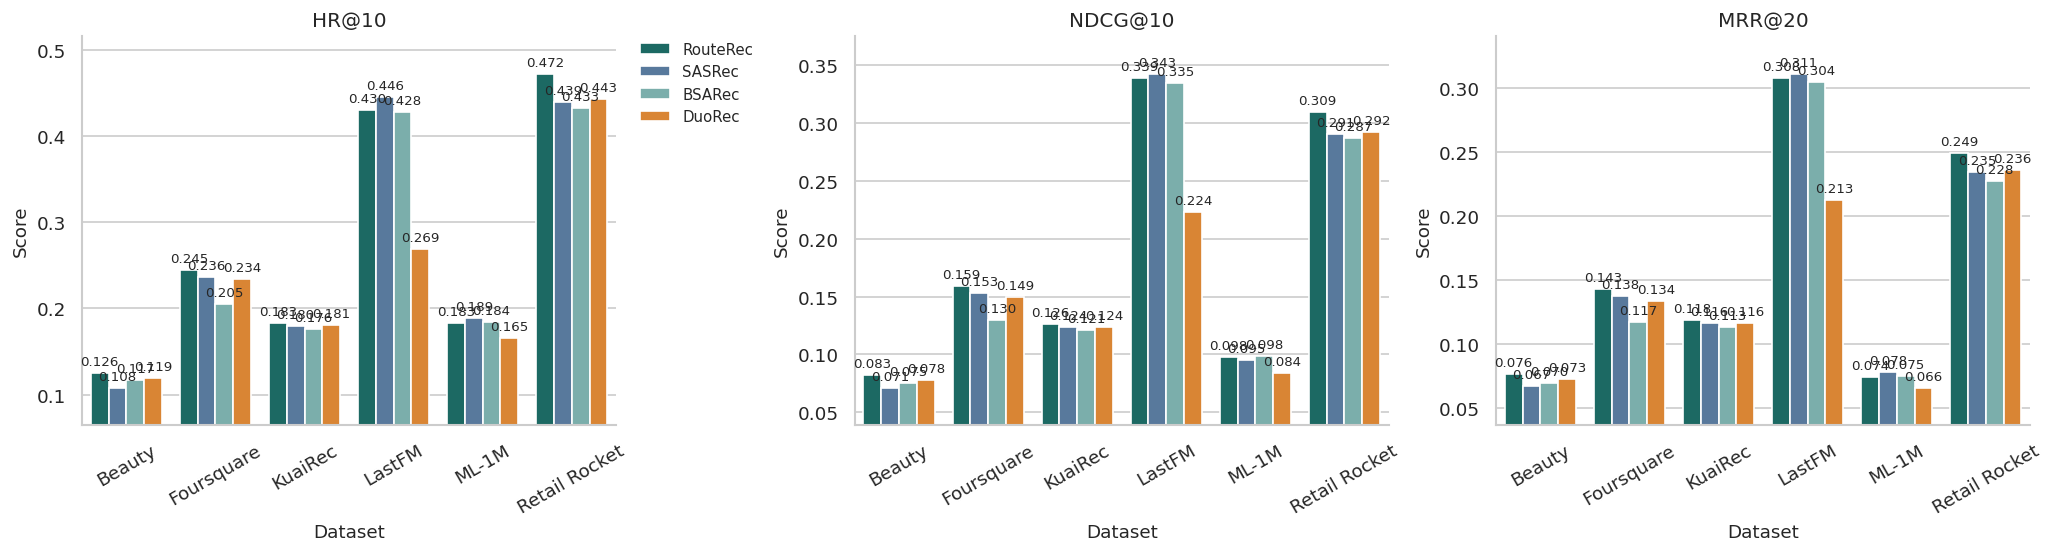

In [4]:
metric_specs = [("HR", 10, "HR@10"), ("NDCG", 10, "NDCG@10"), ("MRR", 20, "MRR@20")]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for ax, (metric, cutoff, title) in zip(axes, metric_specs):
    subset = df[(df["metric"] == metric) & (df["cutoff"] == cutoff)].copy()
    grouped_barplot(
        subset,
        x="dataset",
        hue="variant_or_model",
        y="value",
        ax=ax,
        title=title,
        ylabel="Score",
        xlabel="Dataset",
        rotate=30,
    )
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.02))
saved_paths = export_figure(fig, "01_main_overall_overview", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
